# Segmentación de clientes

In [ ]:
# pandas: para manipular datos en formato tabular (DataFrames)
import pandas as pd
# numpy: para operaciones numéricas (usado internamente por otras librerías)
import numpy as np
# matplotlib.pyplot: para crear gráficos estáticos
import matplotlib.pyplot as plt
# seaborn: para gráficos estadísticos más atractivos (ej: matriz de correlació}n)
import seaborn as sns
# RobustScaler: elimina la mediana y escala los datos según el rango intercuartílico (IQR), necesario para K-means
from sklearn.preprocessing import RobustScaler
# KMeans: algoritmo de clustering no supervisado que agrupa datos en K clusters
from sklearn.cluster import KMeans
# silhouette_score: métrica para evaluar la calidad de los clusters (valores entre -1 y 1; cuanto más alto, mejor)
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [ ]:
df_full = pd.read_csv('/content/drive/MyDrive/Aprendizaje - Automatico/C8/kmeans_3clusters.csv')

# EDA

In [ ]:
# Muestra las primeras 5 filas para verificar la estructura
print("Primeras filas del dataset:")
print(df_full.head())

Primeras filas del dataset:
   purchase_freq_month  avg_basket_usd  time_on_site_min  \
0            11.152508      181.300834         33.564036   
1            12.053451      178.637272         35.432081   
2             2.203006      450.185298          7.030757   
3             4.233314       89.006342         10.834453   
4             1.716799      449.773982          7.254548   

   discount_sensitivity  returns_rate  noise_gauss  noise_uniform  
0              1.000000      0.800000    -1.806578      -2.516905  
1              0.784974      0.000000     0.645129       2.115460  
2              0.898297      0.000000    -0.047406      -0.724173  
3              0.000000      0.800000     0.901700      -2.974026  
4              0.000000      0.003279     0.386013       2.424522  


Se observa 2 columnas noise_gauss y noise_uniform las cuales no utilizaremos para nuestro analisis, por lo que realizaremos una copia del dataset sin estas.

In [ ]:
# Seleccionamos solo las 5 columnas originales del problema de segmentación de clientes

columnas_relevantes = [
    'purchase_freq_month',
    'avg_basket_usd',
    'time_on_site_min',
    'discount_sensitivity',
    'returns_rate'
]
df = df_full[columnas_relevantes].copy()  # .copy() evita advertencias de Pandas

In [ ]:
# Muestra las primeras 5 filas para verificar la estructura
print("Primeras filas del dataset:")
print(df.head())

Primeras filas del dataset:
   purchase_freq_month  avg_basket_usd  time_on_site_min  \
0            11.152508      181.300834         33.564036   
1            12.053451      178.637272         35.432081   
2             2.203006      450.185298          7.030757   
3             4.233314       89.006342         10.834453   
4             1.716799      449.773982          7.254548   

   discount_sensitivity  returns_rate  
0              1.000000      0.800000  
1              0.784974      0.000000  
2              0.898297      0.000000  
3              0.000000      0.800000  
4              0.000000      0.003279  


In [ ]:
# Información general: número de filas, tipo de datos, valores no nulos
print("\nInformación general:")
print(df.info())


Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   purchase_freq_month   700 non-null    float64
 1   avg_basket_usd        700 non-null    float64
 2   time_on_site_min      700 non-null    float64
 3   discount_sensitivity  700 non-null    float64
 4   returns_rate          700 non-null    float64
dtypes: float64(5)
memory usage: 27.5 KB
None


In [ ]:
# Estadísticas descriptivas: media, desviación, mín, máx, etc.
print("\nEstadísticas descriptivas:")
print(df.describe().T)



Estadísticas descriptivas:
                      count        mean         std        min        25%  \
purchase_freq_month   700.0    5.875724    4.471079   0.100000   2.278418   
avg_basket_usd        700.0  248.173491  154.904372  86.994100  90.766945   
time_on_site_min      700.0   16.784799   12.914111   3.163206   6.603950   
discount_sensitivity  700.0    0.425083    0.431467   0.000000   0.000000   
returns_rate          700.0    0.337194    0.356623   0.000000   0.000000   

                             50%         75%         max  
purchase_freq_month     4.134580   11.214919   14.603388  
avg_basket_usd        180.223799  449.719033  452.973583  
time_on_site_min        9.974407   34.341360   38.348156  
discount_sensitivity    0.296475    1.000000    1.000000  
returns_rate            0.165559    0.800000    0.800000  


Se puede observar como la varable avg_basket_usd que representa el promedio de compra contiene valores muy elevados respecto al resto de las variables. Por lo que se debe escalar para utilizara K-Means.

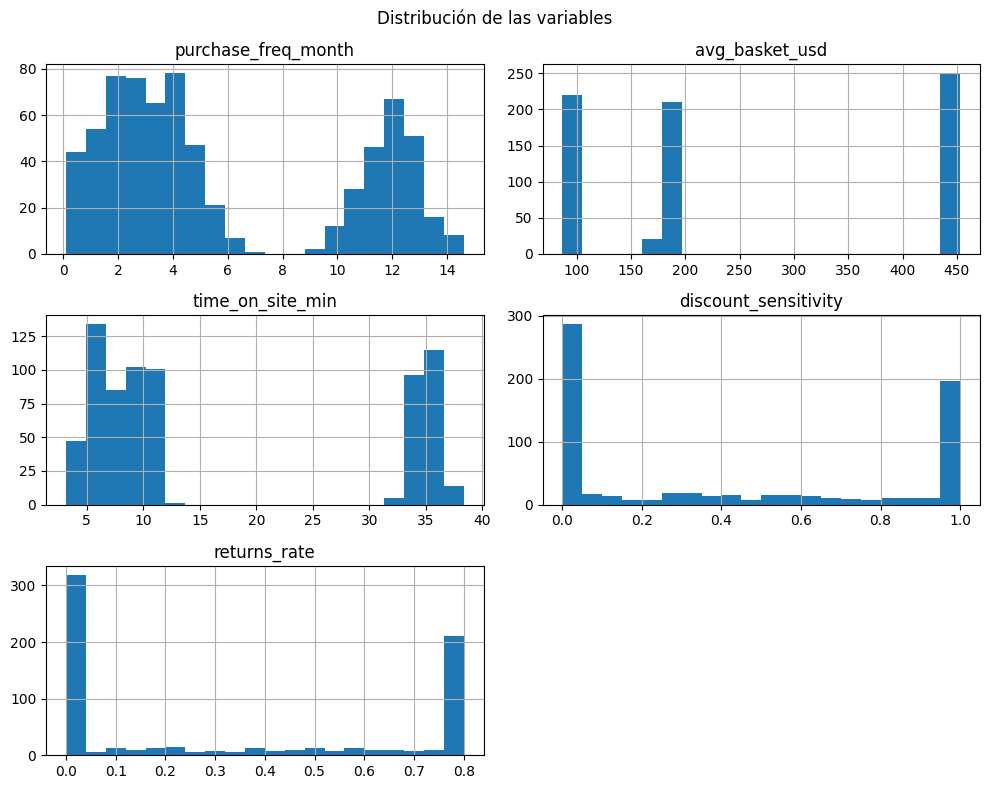

In [ ]:
# Histogramas: muestra la distribución de cada variable
df.hist(bins=20, figsize=(10, 8))
plt.suptitle("Distribución de las variables")
plt.tight_layout()
plt.show()

Analisando los histogramas observamos que:

purchase_freq_month: se observa una distribución bimodal, dividida en muchos clientes con una frecuencia bajas y menos clientes con una frecuencia altas.

avg_basket_usd: Este histograma muestra tres picos distintos, lo que sugiere que podría haber tres grupos de clientes con diferentes tamaños de ticket promedio. Un grupo tiende a tener tickets promedio más pequeñas, otro tickets promedio medias cercanas a pequeñas, mientras que el otro tiene tickets más grandes.

time_on_site_min: Al igual que purchase_freq_month, esta distribución también es bimodal, mostrando que la mayoría de los clientes pasan menos tiempo en el lugar y un número menor pasa más tiempo.

discount_sensitivity: El histograma muestra una concentración de valores en 0 y 1, con menos valores intermedios. Esto sugiere que los clientes no son sensibles a los descuentos (valor cercano a 0) o son muy sensibles (valor cercano a 1), con menos clientes que tienen una sensibilidad moderada.

returns_rate: Similar a discount_sensitivity, este histograma también muestra una concentración de valores en 0 y 0.8, lo que sugiere que los clientes tienen una tasa de devoluciones muy baja (cercana a 0) o una tasa de devoluciones alta (alrededor de 0.8).

Esto nos indica que la dristribucion de los datos no es homogenia, indicando laa existencia de segmentacion dentro de los datos.

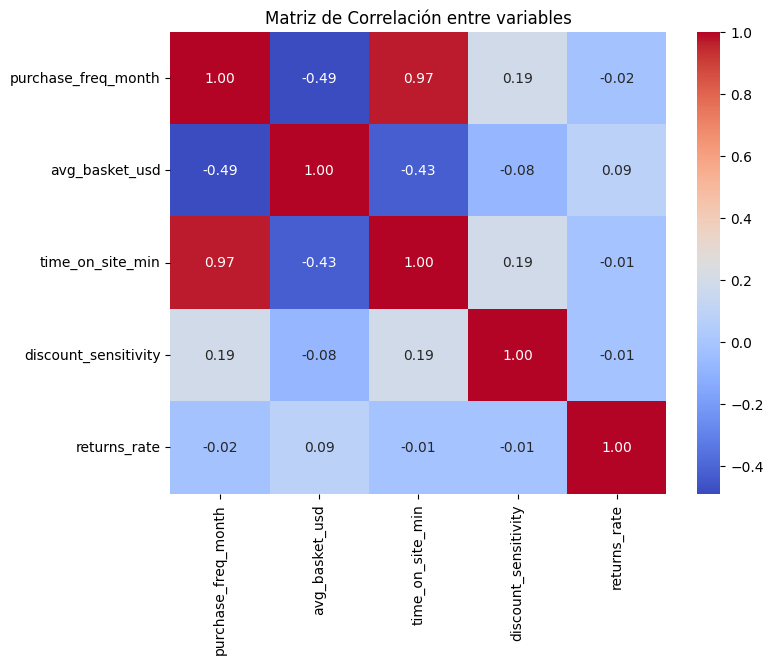

In [ ]:
# Matriz de correlación: muestra relaciones lineales entre pares de variables
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación entre variables")
plt.show()

Analisis de Correlacion:

Se observa una correlacion positiva fuerte entre purchase_freq_month y time_on_site_min de 0,97. Esto quiere decir que los clientes que compran con más frecuencia podrían pasar más tiempo en el lugar.

Hay una correlación negativa moderada entre avg_basket_usd y purchase_freq_month de -0,49. Esto sugiere que los clientes que mas gastan pueden no ser los que mas frecuentan el lugar.

Tambien hay una correlación negativa moderada entre avg_basket_usd y time_on_site_min de -0,43. Esto sugiere que los clientes que mas gastan pueden no ser los que mas tiempo pasan en el lugar.

El resto de correlaciones son casi nulas.

Con esta matriz se observa las relaciones entre las diferentes características de los clientes, lo cual es útil para la segmentación. Por ejemplo, se puede esperar que los grupos de clientes se (Clasifiquen) segun el valor de la compra, tiempo transcurrido en el lugar y frecuencia con la que visitan el lugar.

# Preprocesamiento

In [ ]:
# utilizaremos robustscaler para estandarizar las variables

scaler = RobustScaler()
df_scaled = scaler.fit_transform(df)

# Convertir el array a dataframe y mostramos para verificar.

df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

print("Primeras filas del dataset escalado:")
print(df_scaled.head())

Primeras filas del dataset escalado:
   purchase_freq_month  avg_basket_usd  time_on_site_min  \
0             0.785310        0.003000          0.850463   
1             0.886127       -0.004420          0.917810   
2            -0.216144        0.752082         -0.106126   
3             0.011048       -0.254122          0.031007   
4            -0.270551        0.750936         -0.098057   

   discount_sensitivity  returns_rate  
0              0.703525      0.793051  
1              0.488499     -0.206949  
2              0.601822     -0.206949  
3             -0.296475      0.793051  
4             -0.296475     -0.202851  


In [ ]:
# Comparamos K = 2, 3, 4, 5, 6 usando inercia y silhouette

K_range = range(2, 7)

# Listas para guardar las métricas de cada K
inertias = []           # Inercia (WCSS): suma de distancias al cuadrado dentro de cada cluster
silhouette_scores = []  # silhouette: calidad de separación entre clusters

# Imprime encabezado de la tabla de comparación
print("Comparación de K usando Inercia y Coeficiente de silhouette:\n")
print(f"{'K':<5} {'Inercia':<15} {'silhouette':<10}")
print("-" * 35)

# Bucle: para cada valor de K, entrena K-means y calcula ambas métricas
for k in K_range:

    kmeans = KMeans(n_clusters=k,
                    init="k-means++",
                    n_init=20,
                    max_iter=500,
                    random_state=42
                    )

    # Entrena el modelo y obtiene las etiquetas de cluster para cada cliente
    cluster_labels = kmeans.fit_predict(df_scaled)

    # Guarda la inercia del modelo (atributo inertia_)
    inertia = kmeans.inertia_
    inertias.append(inertia)

    # Calcula el coeficiente de silhouette: mide qué tan bien separados están los clusters
    sil_score = silhouette_score(df_scaled, cluster_labels)
    silhouette_scores.append(sil_score)

    # Muestra los resultados en formato de tabla
    print(f"{k:<5} {inertia:<15.2f} {sil_score:<10.4f}")

Comparación de K usando Inercia y Coeficiente de silhouette:

K     Inercia         silhouette
-----------------------------------
2     401.75          0.4327    
3     272.96          0.4367    
4     226.27          0.4373    
5     186.23          0.4635    
6     147.15          0.4595    


Analisis de la Tabla:

La inercia: Este valor mide que tan compactos son los clusters. Una menor inercia indica que los puntos dentro de cada cluster están más cerca de su centroide. Se busca el punto donde la direccion de la inercia cambia fuertemente, dandole forma al codo.

Silhouette: Esta métrica mide qué tan bien separados están los clusters y qué tan bien asignado está cada punto a su propio cluster. Los valores van de -1 a 1:

Cercano a 1: El punto está muy bien asignado a su cluster y bien separado de otros clusters.

Cercano a 0: El punto está cerca del límite entre dos clusters.

Cercano a -1: El punto podría haber sido asignado incorrectamente.

Con los graficos se analizara los resultados con el K correcto.



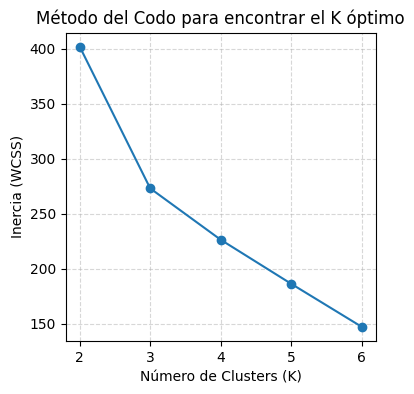

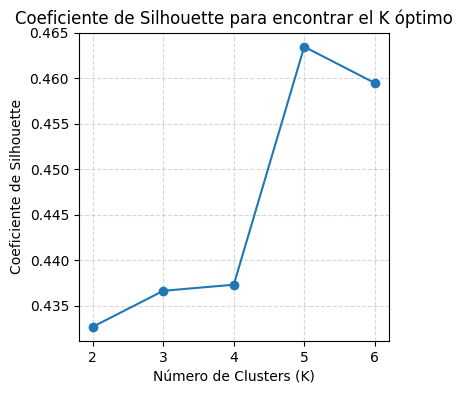

In [ ]:
# Grafico del Codo (inercia)

plt.figure(figsize=(4, 4))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (WCSS)')
plt.title('Método del Codo para encontrar el K óptimo')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# Grafico de silhouette

plt.figure(figsize=(4, 4))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Coeficiente de Silhouette')
plt.title('Coeficiente de Silhouette para encontrar el K óptimo')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Observando los valores de la tabla y los graficos llegamos a la conclusion de:

La inercia disminuye consistentemente a medida que K aumenta. Es difícil identificar un "codo" claro solo con la tabla, pero la disminución es significativa en K=3, y luego se ralentiza un poco.

El Coeficiente de Silhouette aumenta de K=2 a K=3, luego ligeramente a K=4, alcanza su valor más alto en K=5 (0.4635) y luego disminuye ligeramente en K=6.

Podemos confirmar el número óptimo de clusters que seleccionamos (K=5 según el coeficiente de silhouette) ya que nos muestra una mejor claridad de separación y compactacion de los clusters. A diferencia de la inercia la cual no muestra claramente un codo ademas de no tener en cuenta la separacion entre los clusters.

# Entrenamiento y Prueba

In [ ]:
# Encuentra el valor de K que maximiza el coeficiente de silueta
best_k_sil = K_range[np.argmax(silhouette_scores)]
max_sil = max(silhouette_scores)

# Usa este K como el número óptimo de clusters
K_optimo = best_k_sil

# Entrena el modelo final de K-means con el K óptimo
kmeans_final = KMeans(n_clusters=K_optimo, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(df_scaled)

# Añade la columna 'cluster' al DataFrame original para análisis posterior
df['cluster'] = clusters

In [ ]:
# Muestra cuántos clientes hay en cada cluster (balance de clusters)
print("\nTamaño de cada cluster:")
print(df['cluster'].value_counts().sort_index())


Tamaño de cada cluster:
cluster
0     92
1    128
2    220
3    122
4    138
Name: count, dtype: int64


# Graficos PCA

In [ ]:
# Aplicar PCA para reducir a 2 componentes principales
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Convertir los resultados de PCA a un DataFrame para facilitar la visualización
df_pca = pd.DataFrame(df_pca, columns=['PCA Componente 1', 'PCA Componente 2'])

# Añadir las etiquetas de cluster al DataFrame de PCA
df_pca['cluster'] = df['cluster']

# Mostrar las primeras filas del DataFrame de PCA
print("Primeras filas del dataset después de PCA:")
print(df_pca.head())

Primeras filas del dataset después de PCA:
   PCA Componente 1  PCA Componente 2  cluster
0          0.914608          0.639457        0
1          1.026041         -0.337675        4
2         -0.609474         -0.359481        1
3         -0.181264          0.452792        2
4         -0.790486         -0.386881        1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


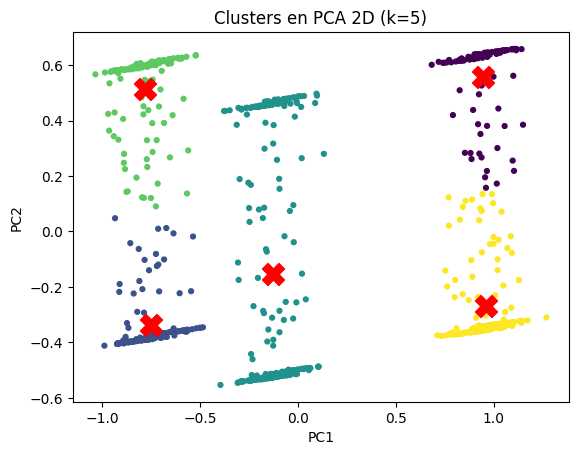

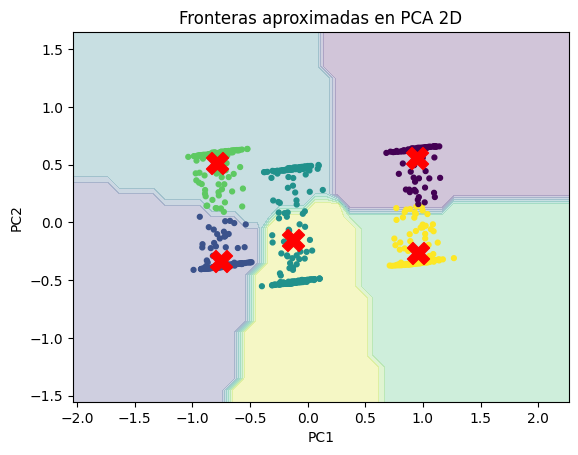

In [ ]:
#Reducimos a 2D para graficar
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(df_scaled)
centers_2d = pca.transform(kmeans_final.cluster_centers_)

#Puntos por cluster
plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, s=12)
plt.scatter(centers_2d[:, 0], centers_2d[:, 1], marker='X', s=250, c='red')
plt.title(f"Clusters en PCA 2D (k={K_optimo})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

#Fronteras aproximadas sobre la proyección 2D (estimativa)
h = 0.1
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid2d = np.c_[xx.ravel(), yy.ravel()]

# Voy a entrenar un nuevo modelo K-Means con el K óptimo (5) usando los datos 2D de PCA
kmeans_pca_2d = KMeans(n_clusters=K_optimo, random_state=42, n_init=10)
kmeans_pca_2d.fit(X_2d)
Z = kmeans_pca_2d.predict(grid2d).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.25)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, s=12)
plt.scatter(centers_2d[:, 0], centers_2d[:, 1], marker='X', s=250, c='red')
plt.title("Fronteras aproximadas en PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Perfiles Clientes Clusteres K = 5

In [ ]:
# Definir las variables relevantes
variables_cliente = [
    'purchase_freq_month',
    'avg_basket_usd',
    'time_on_site_min',
    'discount_sensitivity',
    'returns_rate'
]

# Usar el dataframe original 'df' que ahora contiene la columna 'cluster'
df_base = df[variables_cliente]
q = df_base.quantile([0.25, 0.5, 0.75])
q1 = q.loc[0.25]
q2 = q.loc[0.50]
q3 = q.loc[0.75]

# Calcular los centroides (medias) de las variables por cluster
centers_original = df.groupby('cluster')[variables_cliente].mean()

def tag_level(val, col):
    """Etiqueta el valor como 'bajo', 'medio' o 'alto' basado en los cuartiles del dataset total."""
    # Asegurarse de que la columna exista en los cuartiles calculados
    if col not in q1.index:
        return "desconocido" # O manejar el error de otra manera
    if val <= q1[col]: return "bajo"
    if val >= q3[col]: return "alto"
    return "medio"

profiles = []
for i, row in centers_original.iterrows():
    desc = []
    # Iteramos sobre las columnas del df_base para asegurar el orden y el nombre correcto
    for col in df_base.columns:
        level = tag_level(row[col], col)
        desc.append(f"{col}: {level} ({row[col]:.2f})")
    profiles.append((i, "; ".join(desc)))

print(" Perfiles de Clientes (Basado en Cuartiles) ")
for cid, txt in profiles:
    print(f"Cluster {cid}: {txt}")

 Perfiles de Clientes (Basado en Cuartiles) 
Cluster 0: purchase_freq_month: alto (12.02); avg_basket_usd: medio (179.98); time_on_site_min: alto (35.20); discount_sensitivity: medio (0.56); returns_rate: medio (0.74)
Cluster 1: purchase_freq_month: bajo (1.88); avg_basket_usd: alto (450.19); time_on_site_min: bajo (5.87); discount_sensitivity: medio (0.36); returns_rate: medio (0.04)
Cluster 2: purchase_freq_month: medio (4.09); avg_basket_usd: bajo (89.96); time_on_site_min: medio (10.00); discount_sensitivity: medio (0.38); returns_rate: medio (0.30)
Cluster 3: purchase_freq_month: bajo (1.81); avg_basket_usd: alto (450.05); time_on_site_min: bajo (6.08); discount_sensitivity: medio (0.35); returns_rate: medio (0.73)
Cluster 4: purchase_freq_month: alto (11.92); avg_basket_usd: medio (180.01); time_on_site_min: alto (34.90); discount_sensitivity: medio (0.53); returns_rate: medio (0.06)


## Analisis K = 5

Cluster 0: Compradores Frecuentes

purchase_freq_month: Alto (12.02) - Compran muy frecuentemente.

avg_basket_usd: Medio (179.98) - El monto de sus compras es moderado.

time_on_site_min: Alto (35.20) - Pasan bastante tiempo en el sitio.

discount_sensitivity: Medio (0.56) - Sensibilidad moderada a descuentos.

returns_rate: Medio (0.74) - Tienen una tasa de devoluciones relativamente alta.

Clientes que visitan y compran a menudo, pasan mucho tiempo en el sitio, pero sus compras no son las más grandes. Podrían ser sensibles a las devoluciones.

Cluster 1: Grandes Compradores Ocasionales

purchase_freq_month: Bajo (1.88) - Compran con poca frecuencia.

avg_basket_usd: Alto (450.19) - Tienen un ticket promedio muy alto.

time_on_site_min: Bajo (5.87) - Pasan poco tiempo en el sitio.

discount_sensitivity: Medio (0.36) - Baja sensibilidad a descuentos.

returns_rate: Medio (0.04) - Tasa de devoluciones muy baja.

Clientes que compran rara vez, pasan poco tiempo en el sitio, pero cuando lo hacen, gastan mucho y casi nunca devuelven productos. Son clientes de alto valor transaccional.

Cluster 2: Clientes de bajo Valor

purchase_freq_month: Medio (4.09) - Frecuencia de compra moderada a baja.

avg_basket_usd: Bajo (89.96) - Tienen un ticket promedio bajo.

time_on_site_min: Medio (10.00) - Pasan una cantidad moderada de tiempo en el sitio.

discount_sensitivity: Medio (0.38) - Baja sensibilidad a descuentos.

returns_rate: Medio (0.30) - Tasa de devoluciones moderada.

Clientes con métricas generalmente bajas en casi todas las variables. Compran con poca frecuencia, gastan poco por compra, y no pasan mucho tiempo en el sitio.

Cluster 3: Grandes compradores con Altas Devoluciones

purchase_freq_month: Bajo (1.81) - Compran con poca frecuencia.

avg_basket_usd: Alto (450.05) - Tienen un ticket promedio muy alto.

time_on_site_min: Bajo (6.08) - Pasan poco tiempo en el sitio.

discount_sensitivity: Medio (0.35) - Baja sensibilidad a descuentos.

returns_rate: Medio (0.73) - Tienen una tasa de devoluciones relativamente alta.

Similar al Cluster 1 en frecuencia de compra, ticket promedio alto y bajo tiempo en el sitio, pero se diferencian por tener una tasa de devoluciones alta.

Cluster 4: Compradores Frecuentes

purchase_freq_month: Alto (11.92) - Compran muy frecuentemente.

avg_basket_usd: Medio (180.01) - El monto de sus compras es moderado.

time_on_site_min: Alto (34.90) - Pasan bastante tiempo en el sitio.

discount_sensitivity: Medio (0.53) - Sensibilidad moderada a descuentos.

returns_rate: Medio (0.06) - Tasa de devoluciones muy baja.

Similar al Cluster 0 en alta frecuencia de compra y tiempo en el sitio y ticket promedio medio, pero se diferencian por tener una tasa de devoluciones muy baja.

# Prueba con K =3 Codo

In [ ]:
# Definimos el valor de K=3
k_alternativo = 3

# Entrenamiento con K=3
kmeans_k3 = KMeans(
    n_clusters=k_alternativo,
    init='k-means++',
    n_init=20,
    random_state=42
)
labels_k3 = kmeans_k3.fit_predict(df_scaled)

# Etiquetar K=3 en el dataframe
df['Cluster_K3'] = labels_k3

# Calculo de metricas para K=3
inercia_k3 = kmeans_k3.inertia_
silhouette_k3 = silhouette_score(df_scaled, labels_k3)

# Calculo de centroides para K=3
centers_original_k3 = df.groupby('Cluster_K3')[variables_cliente].mean().round(2)

print(f" Evaluación del Modelo K={k_alternativo} ")
print(f"Inercia (WCSS) (K=3): {inercia_k3:.2f}")
print(f"Puntaje de Silueta (K=3): {silhouette_k3:.4f}")
print("\n Matriz de Centroides (K=3) (Perfil de Gasto Simple) ")
print(centers_original_k3)

 Evaluación del Modelo K=3 
Inercia (WCSS) (K=3): 272.96
Puntaje de Silueta (K=3): 0.4367

 Matriz de Centroides (K=3) (Perfil de Gasto Simple) 
            purchase_freq_month  avg_basket_usd  time_on_site_min  \
Cluster_K3                                                          
0                         11.96          180.00             35.02   
1                          1.85          450.12              5.97   
2                          4.09           89.96             10.00   

            discount_sensitivity  returns_rate  
Cluster_K3                                      
0                           0.54          0.33  
1                           0.36          0.38  
2                           0.38          0.30  


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


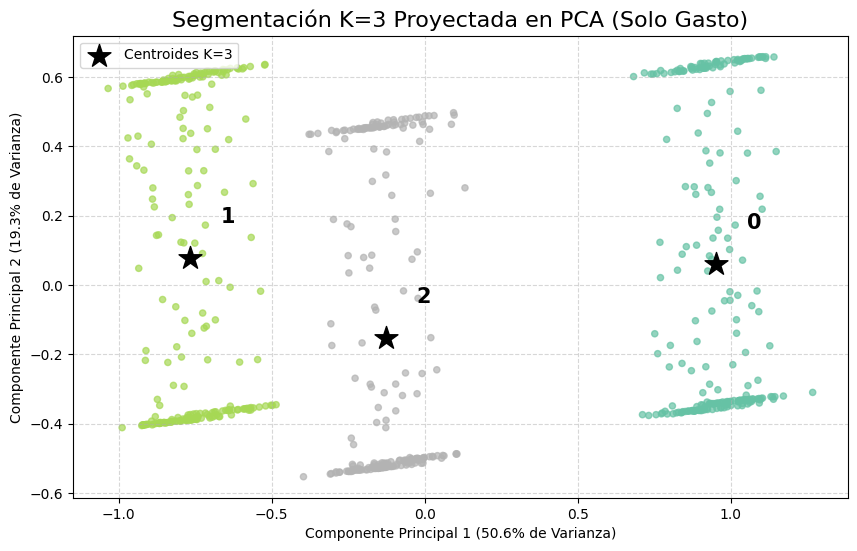

In [ ]:
# Visualización con PCA para K=3

# Proyección de Centroides K=3 en el PCA ajustado
centers_k3_2d = pca.transform(kmeans_k3.cluster_centers_)

# Gráfico de Dispersión PCA para K=3
plt.figure(figsize=(10, 6))

# Dibujamos los puntos con las nuevas etiquetas de K=3
plt.scatter(X_2d[:, 0], X_2d[:, 1],
            c=labels_k3, s=20, cmap='Set2', alpha=0.7) # Usamos Set2 para diferenciar del K=5

# Dibujamos los Centroides K=3
plt.scatter(centers_k3_2d[:, 0], centers_k3_2d[:, 1], marker='*', s=300, color='black', label='Centroides K=3')

# Añadir etiquetas de texto a los centroides
for i, centroide in enumerate(centers_k3_2d):
    plt.text(centroide[0] + 0.1, centroide[1] + 0.1, str(i), fontsize=15, weight='bold', color='black')

plt.title(f'Segmentación K=3 Proyectada en PCA (Solo Gasto)', fontsize=16)
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% de Varianza)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% de Varianza)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# Re-calcular la matriz de centroides usando la columna 'Cluster_K3'
# Esto genera el centroide para el modelo alternativo de K=3
centers_original_k3 = df.groupby('Cluster_K3')[variables_cliente].mean()

profiles_k3 = []
# Iteramos sobre la nueva matriz de centroides (centers_original_k3)
for i, row in centers_original_k3.iterrows():
    desc = []
    for col in df_base.columns:
        level = tag_level(row[col], col)
        desc.append(f"{col}: {level} ({row[col]:.2f})")
    profiles_k3.append((i, "; ".join(desc)))

print("\n Perfiles de Clientes (K=3) Basado en Cuartiles del Dataset Total ")
for cid, txt in profiles_k3:
    print(f"Cluster {cid}: {txt}")


 Perfiles de Clientes (K=3) Basado en Cuartiles del Dataset Total 
Cluster 0: purchase_freq_month: alto (11.96); avg_basket_usd: medio (180.00); time_on_site_min: alto (35.02); discount_sensitivity: medio (0.54); returns_rate: medio (0.33)
Cluster 1: purchase_freq_month: bajo (1.85); avg_basket_usd: alto (450.12); time_on_site_min: bajo (5.97); discount_sensitivity: medio (0.36); returns_rate: medio (0.38)
Cluster 2: purchase_freq_month: medio (4.09); avg_basket_usd: bajo (89.96); time_on_site_min: medio (10.00); discount_sensitivity: medio (0.38); returns_rate: medio (0.30)


## Analisis Clusteres K = 3

Podemos observar como se dividen en 3 Clusteres claros.

Cluster 0: Compradores Frecuentes con Gasto Medio

purchase_freq_month: Alto (11.96) - Compran muy frecuentemente.

avg_basket_usd: Medio (180.00) - El monto de sus compras es moderado.

time_on_site_min: Alto (35.02) - Pasan bastante tiempo en el sitio.

discount_sensitivity: Medio (0.54) - Sensibilidad moderada a descuentos.

returns_rate: Medio (0.33) - Tienen una tasa de devoluciones moderada.

Clientes que visitan y compran a menudo, pasan mucho tiempo en el sitio, pero sus compras no son las más grandes. Podrían tener una tasa de devoluciones moderada.

Cluster 1: Grandes Compradores Ocasionales

purchase_freq_month: Bajo (1.85) - Compran con poca frecuencia.

avg_basket_usd: Alto (450.12) - Tienen un ticket promedio muy alto.

time_on_site_min: Bajo (5.97) - Pasan poco tiempo en el sitio.

discount_sensitivity: Medio (0.36) - Baja sensibilidad a descuentos.

returns_rate: Medio (0.38) - Tienen una tasa de devoluciones moderada.

Clientes que compran rara vez, pasan poco tiempo en el sitio, pero cuando lo hacen, gastan mucho. Tienen una sensibilidad baja a descuentos y una tasa de devoluciones moderada.

Cluster 2: Clientes de Bajo Valor

purchase_freq_month: Medio (4.09) - Frecuencia de compra moderada a baja.

avg_basket_usd: Bajo (89.96) - Tienen un ticket promedio bajo.

time_on_site_min: Medio (10.00) - Pasan una cantidad moderada de tiempo en el sitio.

discount_sensitivity: Medio (0.38) - Baja sensibilidad a descuentos.

returns_rate: Medio (0.30) - Tasa de devoluciones moderada.

Clientes con métricas generalmente bajas en casi todas las variables. Compran con poca frecuencia, gastan poco por compra, y no pasan mucho tiempo en el sitio. Tienen baja sensibilidad a descuentos y una tasa de devoluciones moderada.

En comparación con el análisis de K=5, la segmentación con K=3 ofrece una vista más general, combinando algunos de los subgrupos que se separaron en K=5 (por ejemplo, en K=5 teníamos dos grupos de "Grandes Compradores Ocasionales", uno con alta y otro con baja tasa de devolución, que aquí se agrupan en el Cluster 1). El análisis de K=5 proporcionó una segmentación mayor, especialmente en los comportamientos de "Grandes Compradores" y "Compradores Frecuentes" en relación con su tasa de devoluciones.